<!-- auditkit-logo-cell -->
<p align="center">
  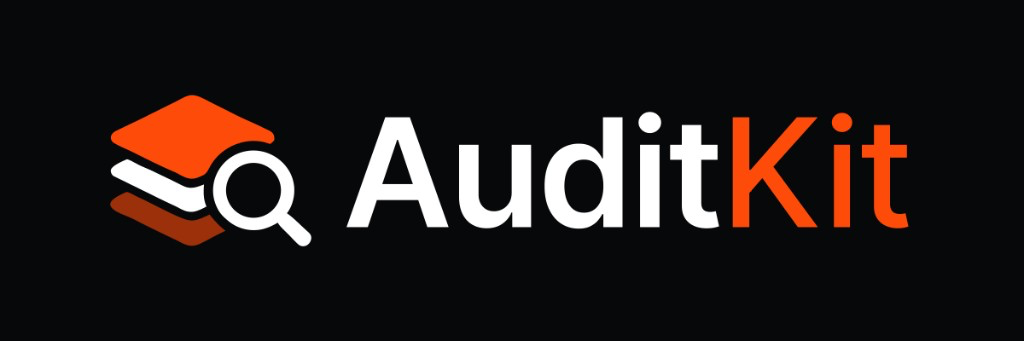
</p>

# AuditKit — `EncoderJudge`: the base mechanism + its 2 prebuilt subclasses

**No GPU needed** -- every checkpoint here is small enough for CPU (largest
is DeBERTa-base at ~140M params). Runs locally or on Colab; the first cell
below detects Colab and self-installs `auditkit` from source.

`EncoderJudge` is a fundamentally different judge *mechanism* from
`LLMJudge`/`GEval`: instead of asking a second LLM to generate free text
and parsing a verdict out of it, it runs your candidate + reference through
a real `AutoModelForSequenceClassification` encoder in **one forward
pass** and reads the classifier's own label probabilities directly -- no
generation, no parsing, deterministic, no API cost.

This notebook tests:

1. The base mechanism directly (pair-sequence tokenizer encoding, label
   mapping, aggregation modes)
2. `FactualityEncoderJudge` -- entailment/factual-consistency, zero-config
3. `SentimentEncoderJudge` -- 2-way sentiment, single-sequence, zero-config
4. Both prebuilts scoring the same run together in one `evaluate()` call
5. The worked example for a checkpoint with only generic labels (no
   dedicated class needed -- `label_map=` does the same job)
6. Constructor overrides (`aggregation=`, `label_map=`, custom `model_name=`)


In [1]:
# Colab bootstrap -- clones and installs auditkit from source (no PyPI
# package exists yet). No-op outside Colab.
import sys, subprocess, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import getpass
    REPO_DIR = "/content/AuditKit-mirror"
    if not os.path.exists(REPO_DIR):
        github_token = os.environ.get("GITHUB_TOKEN") or getpass.getpass("GitHub token (needs repo access): ")
        repo_url = f"https://{github_token}@github.com/utsavavaiya-sudo/AuditKit-mirror.git"
        clone = subprocess.run(
            ["git", "clone", "-b", "continue-removal-branch", "-q", repo_url, REPO_DIR],
            capture_output=True, text=True,
        )
        if clone.returncode != 0:
            # Never let a CalledProcessError propagate here -- its default
            # repr includes process.args, which contains the token embedded
            # in repo_url. Anyone who copy-pastes that traceback (e.g. into
            # a chat) leaks their token. Raise a clean, redacted error instead.
            raise RuntimeError(
                "git clone failed:\n" + clone.stderr.replace(github_token, "<redacted>") +
                "\nCommon causes: token missing 'repo' scope (classic PAT) or "
                "'Contents: Read' permission on this repo (fine-grained PAT), "
                "token not authorized for this org (SSO), or your account isn't "
                "a collaborator on this repo."
            )
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", f"{REPO_DIR}[transformers]"], check=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, f"{REPO_DIR}/src")
    print("Colab detected -- auditkit installed from source at", REPO_DIR)
else:
    print("Not running in Colab -- assuming auditkit is already installed locally with [transformers].")


Colab detected -- auditkit installed from source at /content/AuditKit-mirror


In [2]:
import auditkit as ak
from auditkit import Sample
from auditkit.metrics.encoder_judge import EncoderJudge, FactualityEncoderJudge, SentimentEncoderJudge

print("auditkit version:", ak.__version__)


auditkit version: 0.3.0


---
## 1. The base mechanism: pair-sequence encoding, label mapping, aggregation

`text_template=`/`text_pair_template=` decide what fills the tokenizer's
two real input slots (`[CLS] text [SEP] text_pair [SEP]`) -- the "template"
question for an encoder isn't a prompt string, it's which fields go where.
`label_map` auto-detects from real label names when the checkpoint has
them (`ENTAILMENT`/`NEUTRAL`/`CONTRADICTION` here).


In [3]:
base_judge = EncoderJudge(model_name="microsoft/deberta-base-mnli")

sample = Sample(input="q", target="The cat sat on the mat.")
identical = base_judge.score(sample, "The cat sat on the mat.")
unrelated = base_judge.score(sample, "A completely unrelated sentence about rockets.")

print("identical text:", identical.value, "| reason:", identical.reason)
print("unrelated text:", unrelated.value, "| reason:", unrelated.reason)
print("full probability distribution:", identical.metadata["probabilities"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/557M [00:00<?, ?B/s]

Some weights of the model checkpoint at microsoft/deberta-base-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


identical text: 0.9977846404071897 | reason: predicted='ENTAILMENT' probability=0.996 aggregation=probability
unrelated text: 0.021730547305196524 | reason: predicted='CONTRADICTION' probability=0.964 aggregation=probability
full probability distribution: {'ENTAILMENT': 0.9958123564720154, 'NEUTRAL': 0.003944567870348692, 'CONTRADICTION': 0.00024302667588926852}


In [4]:
# Aggregation modes: "probability" (confidence-weighted sum, default) vs
# "argmax" (just the top label's mapped value -- more binary-flavored).
prob_judge = EncoderJudge(model_name="microsoft/deberta-base-mnli", aggregation="probability")
argmax_judge = EncoderJudge(model_name="microsoft/deberta-base-mnli", aggregation="argmax")

print("probability aggregation:", prob_judge.score(sample, "The cat sat on the mat.").value)
print("argmax aggregation:     ", argmax_judge.score(sample, "The cat sat on the mat.").value)


Some weights of the model checkpoint at microsoft/deberta-base-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


probability aggregation: 0.9977846404071897


Some weights of the model checkpoint at microsoft/deberta-base-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


argmax aggregation:      1.0


---
## 2. `FactualityEncoderJudge` -- entailment/factual-consistency, zero-config

DeBERTa v1 (`microsoft/deberta-base-mnli`), real label names, nothing to
configure. This is the general-purpose default for "does this answer hold
up against the reference?"


In [5]:
factuality = FactualityEncoderJudge()

print("Zero-config discrimination test:")
print("  identical:", factuality.score(sample, "The cat sat on the mat.").value)
print("  unrelated:", factuality.score(sample, "A completely unrelated sentence about rockets.").value)

print()
print("Real evaluate() pipeline:")
r = ak.evaluate(
    [Sample(input="What is the capital of France?", target="The capital of France is Paris.")],
    model=lambda p: ["The capital of France is Paris."],
    scorers=[factuality],
)
print(r.headline)


Zero-config discrimination test:


Some weights of the model checkpoint at microsoft/deberta-base-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


  identical: 0.9977846404071897
  unrelated: 0.021730547305196524

Real evaluate() pipeline:
{'factuality_encoder_judge': 0.9981642462080345}


---
## 3. `SentimentEncoderJudge` -- 2-way sentiment, single-sequence, zero-config

DistilBERT (`distilbert-base-uncased-finetuned-sst-2-english`). The only
prebuilt with a genuinely different task from `FactualityEncoderJudge` --
judges the tone of **one** piece of text, no reference/`target` needed
(`text_pair_template=None`).

**A real caveat, confirmed below, not asserted**: this checkpoint is
strictly **binary** (positive/negative) -- there's no neutral class. A
genuinely neutral sentence doesn't land in the middle; it just gets
pushed toward whichever of the two labels edges out, which can look
surprisingly confident for text that isn't really "positive" at all.


In [6]:
sentiment = SentimentEncoderJudge()

positive_sample = Sample(input="q", target="")  # target unused -- single-sequence mode
print("positive text:", sentiment.score(positive_sample, "I love this!").value)
print("negative text:", sentiment.score(positive_sample, "I hate this!").value)
print("neutral-ish text:", sentiment.score(positive_sample, "The package arrived on Tuesday.").value)
# ^ this one is genuinely neutral content, but scores high (~0.98) --
# not because the model thinks it's positive, but because binary
# classifiers have nowhere else to put "neutral." Not a bug, a real
# limitation of the checkpoint's own training task.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


positive text: 0.9998764991760254
negative text: 0.000423454592237249
neutral-ish text: 0.9829573035240173


---
## 4. Both prebuilts scoring the same run together, one `evaluate()` call

Two completely different tasks (entailment vs. sentiment), same
`scorers=` list -- no special multi-judge API needed, `EncoderJudge`
subclasses are ordinary metrics.


In [7]:
combined_samples = [
    Sample(input="What is the capital of France?", target="The capital of France is Paris."),
]

result = ak.evaluate(
    combined_samples,
    model=lambda p: ["The capital of France is Paris. I'm so glad I could help!"],
    scorers=[factuality, sentiment],
)
print(result.headline)
print(result.summary())


{'factuality_encoder_judge': 0.9961901023052633, 'sentiment_encoder_judge': 0.9992985725402832}
run 6204fd881ace0de3 (fingerprint 6204fd881ace0de3)
  factuality_encoder_judge: 0.9962 ± 0.0000  (n=1)
  sentiment_encoder_judge: 0.9993 ± 0.0000  (n=1)


---
## 5. Worked example: a checkpoint with only generic labels

Not every entailment checkpoint has real label names. `textattack/bert-
base-uncased-MNLI` only exposes generic `LABEL_0/1/2` -- bare
`EncoderJudge` correctly **refuses** to auto-detect (raises rather than
guess), so you determine the real order empirically and pass `label_map=`
explicitly. No dedicated class needed for this -- it's the same
`EncoderJudge`, just with an explicit map.

`howey/electra-base-mnli` also only has generic labels, and its real order
is the **opposite** of BERT's -- proof a generic checkpoint's order can
never be assumed from another checkpoint's convention.


In [8]:
# Confirm the auto-detection refusal first -- this should raise, not guess:
generic_judge = EncoderJudge(model_name="textattack/bert-base-uncased-MNLI")
try:
    generic_judge.score(sample, "The cat sat on the mat.")
    print("FAIL: should have raised")
except ValueError as e:
    print("Correctly refused to auto-detect:", e)


config.json:   0%|          | 0.00/630 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Correctly refused to auto-detect: EncoderJudge: couldn't auto-detect a label_map for this checkpoint's labels ['LABEL_0', 'LABEL_1', 'LABEL_2'] -- pass label_map= explicitly, e.g. label_map={'LABEL_0': 1.0, ...}. Auto-detection only recognizes common NLI/sentiment-style names (entailment/positive/yes -> 1.0, contradiction/negative/no -> 0.0, neutral -> 0.5); a checkpoint with generic labels (LABEL_0/LABEL_1/...) can't be guessed without fabricating what they mean.


In [9]:
# textattack/bert-base-uncased-MNLI: LABEL_0=contradiction, LABEL_1=entailment, LABEL_2=neutral
bert_judge = EncoderJudge(
    model_name="textattack/bert-base-uncased-MNLI",
    label_map={"LABEL_0": 0.0, "LABEL_1": 1.0, "LABEL_2": 0.5},
)

# howey/electra-base-mnli: LABEL_0=entailment, LABEL_1=neutral, LABEL_2=contradiction -- REVERSED
electra_judge = EncoderJudge(
    model_name="howey/electra-base-mnli",
    label_map={0: 1.0, 1: 0.5, 2: 0.0},
)

print("bert_judge (verified map):   ", bert_judge.score(sample, "The cat sat on the mat.").value)
print("electra_judge (reversed map):", electra_judge.score(sample, "The cat sat on the mat.").value)


Device set to use cuda:0


bert_judge (verified map):    0.9888081389945


config.json:   0%|          | 0.00/916 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


electra_judge (reversed map): 0.997802943456918


---
## 6. Constructor overrides

Every prebuilt accepts the exact same arguments as `EncoderJudge` itself
-- the class only changes which values are the *defaults*.


In [10]:
# Override aggregation while keeping FactualityEncoderJudge's checkpoint/labels
argmax_factuality = FactualityEncoderJudge(aggregation="argmax")
print("argmax override:", argmax_factuality.score(sample, "The cat sat on the mat.").value)

# Override the label_map entirely on SentimentEncoderJudge (e.g. both count as pass)
lenient_sentiment = SentimentEncoderJudge(label_map={"POSITIVE": 1.0, "NEGATIVE": 1.0})
print("lenient sentiment override (negative text):", lenient_sentiment.score(positive_sample, "I hate this!").value)

# Swap the underlying checkpoint but keep the class's other defaults --
# only sensible if the replacement's labels actually match what the class
# assumes; otherwise pass label_map= too.
alt_factuality = FactualityEncoderJudge(model_name="microsoft/deberta-base-mnli")
print("custom model_name (same checkpoint here, but the override path works):",
      alt_factuality.score(sample, "The cat sat on the mat.").value)


Some weights of the model checkpoint at microsoft/deberta-base-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


argmax override: 1.0


Device set to use cuda:0


lenient sentiment override (negative text): 0.9999999635911081


Some weights of the model checkpoint at microsoft/deberta-base-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


custom model_name (same checkpoint here, but the override path works): 0.9977846404071897


---
## Summary

- The base `EncoderJudge` mechanism: real tokenizer pair-sequence
  encoding, one forward pass, softmax over the checkpoint's own labels,
  `label_map` turning that into a 0-1 score -- confirmed via real
  discrimination (identical text scores high, unrelated text scores low)
  and both aggregation modes.
- `FactualityEncoderJudge` (entailment/factual-consistency) and
  `SentimentEncoderJudge` (sentiment) are the 2 remaining prebuilts --
  genuinely different tasks, zero-config, fully overridable.
- Both score the same run together in one `evaluate()` call -- no special
  multi-judge API.
- A checkpoint with only generic `LABEL_0/1/2` labels (no dedicated class
  needed) -- `EncoderJudge` correctly refuses to auto-detect, and
  `label_map=` does the same job the old `BertNLIJudge`/`ElectraNLIJudge`
  classes used to, with the real, verified (and confirmed **opposite**
  between BERT/ELECTRA) mapping.

Fill in with what actually happened when you ran it:
- [ ] Section 1 values: paste identical/unrelated scores + full probability distribution
- [ ] Section 4 `result.headline`: paste output
- [ ] Section 5: did the auto-detection refusal raise as expected?
